In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import pickle

# Load preds

In [21]:
with open('./../../results/bawden/bawden_preds', 'rb') as fp:
    preds_bawden = pickle.load(fp)

with open('./../../results/glenreagh/glenreagh_preds', 'rb') as fp:
    preds_glenreagh = pickle.load(fp)

with open('./../../results/richmond/richmond_preds', 'rb') as fp:
    preds_richmond = pickle.load(fp)

# Scatter plot 1:1 for mixture

Text(0.5, 0, 'Observed streamflow stage height in $m$ \n (log scale)')

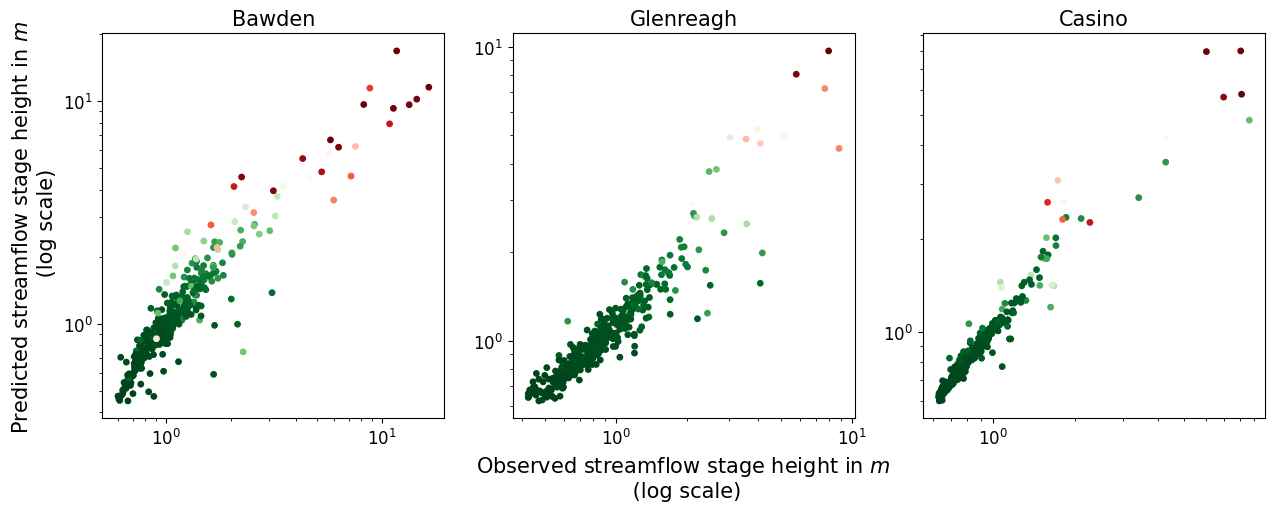

In [31]:

fig = plt.figure(figsize=(15,5))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
gs = fig.add_gridspec(1,3,)
(ax1, ax2, ax3) = gs.subplots()

ax1.scatter(preds_bawden['obs'][np.argwhere(preds_bawden['mix_weights_m2']<0.5)],preds_bawden['preds_m2'][np.argwhere(preds_bawden['mix_weights_m2']<0.5)], label = 'Dominant model1', s=15, c=preds_bawden['mix_weights_m2'][np.argwhere(preds_bawden['mix_weights_m2']<0.5)],cmap='Greens_r')
ax1.scatter(preds_bawden['obs'][np.argwhere(preds_bawden['mix_weights_m2']>=0.5)],preds_bawden['preds_m2'][np.argwhere(preds_bawden['mix_weights_m2']>=0.5)], label = 'Dominant model2', s=15, c=1-preds_bawden['mix_weights_m2'][np.argwhere(preds_bawden['mix_weights_m2']>=0.5)], cmap='Reds_r')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2.scatter(preds_glenreagh['obs'][np.argwhere(preds_glenreagh['mix_weights_m2']<0.5)],preds_glenreagh['preds_m2'][np.argwhere(preds_glenreagh['mix_weights_m2']<0.5)], label = 'Dominant model1', s=15, c=preds_glenreagh['mix_weights_m2'][np.argwhere(preds_glenreagh['mix_weights_m2']<0.5)],cmap='Greens_r')
ax2.scatter(preds_glenreagh['obs'][np.argwhere(preds_glenreagh['mix_weights_m2']>=0.5)],preds_glenreagh['preds_m2'][np.argwhere(preds_glenreagh['mix_weights_m2']>=0.5)], label = 'Dominant model2', s=15, c=1-preds_glenreagh['mix_weights_m2'][np.argwhere(preds_glenreagh['mix_weights_m2']>=0.5)], cmap='Reds_r')
ax2.set_xscale('log')
ax2.set_yscale('log')

ax3.scatter(preds_richmond['obs'][np.argwhere(preds_richmond['mix_weights_m2']<0.5)],preds_richmond['preds_m2'][np.argwhere(preds_richmond['mix_weights_m2']<0.5)], label = 'Dominant model1', s=15, c=preds_richmond['mix_weights_m2'][np.argwhere(preds_richmond['mix_weights_m2']<0.5)],cmap='Greens_r')
ax3.scatter(preds_richmond['obs'][np.argwhere(preds_richmond['mix_weights_m2']>=0.5)],preds_richmond['preds_m2'][np.argwhere(preds_richmond['mix_weights_m2']>=0.5)], label = 'Dominant model2', s=15, c=1-preds_richmond['mix_weights_m2'][np.argwhere(preds_richmond['mix_weights_m2']>=0.5)], cmap='Reds_r')
ax3.set_xscale('log')
ax3.set_yscale('log')

ax2.xaxis.set_tick_params(labelsize=12)
ax2.yaxis.set_tick_params(labelsize=12)
ax3.xaxis.set_tick_params(labelsize=12)
ax3.yaxis.set_tick_params(labelsize=12)
ax1.xaxis.set_tick_params(labelsize=12)
ax1.yaxis.set_tick_params(labelsize=12)
ax1.set_title('Bawden',fontsize=15)
ax2.set_title('Glenreagh',fontsize=15)
ax3.set_title('Casino',fontsize=15)

ax1.set_ylabel('Predicted streamflow stage height in $m$ \n (log scale)',fontsize=15)
ax2.set_xlabel('Observed streamflow stage height in $m$ \n (log scale)',fontsize=15)


# Height duration curves

In [14]:
# Casino
flow_rank_c = np.argsort(preds_richmond['obs'])
f_c = flow_rank_c / len(preds_richmond['obs'])

fc_sort = np.sort(f_c)
fc_argsort = np.argsort(f_c)

discharge_sort_c = np.sort(preds_richmond['obs'])
discharge_argsort_c = np.argsort(preds_richmond['obs'])

discharge_sort_c = np.flip (discharge_sort_c)
discharge_argsort_c = np.flip(discharge_argsort_c)

# Bawden
flow_rank_b = np.argsort(preds_bawden['obs'])
f_b = flow_rank_b / len(preds_bawden['obs'])

fb_sort = np.sort(f_b)
fb_argsort = np.argsort(f_b)

discharge_sort_b = np.sort(preds_bawden['obs'])
discharge_argsort_b = np.argsort(preds_bawden['obs'])

discharge_sort_b = np.flip (discharge_sort_b)
discharge_argsort_b = np.flip(discharge_argsort_b)

#Glenreagh
flow_rank_g = np.argsort(preds_glenreagh['obs'])
f_g = flow_rank_g / len(preds_glenreagh['obs'])

fg_sort = np.sort(f_g)
fg_argsort = np.argsort(f_g)

discharge_sort_g = np.sort(preds_glenreagh['obs'])
discharge_argsort_g = np.argsort(preds_glenreagh['obs'])

discharge_sort_g = np.flip (discharge_sort_g)
discharge_argsort_g = np.flip(discharge_argsort_g)

/root/.local/lib/python3.8/site-packages/jax/_src/numpy/lax_numpy.py:3485: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


In [15]:
# Casino
switch_c = preds_richmond['mix_weights_m2'][discharge_argsort_c]
switch_args1_c = np.argwhere(switch_c<0.5)
switch_args2_c = np.argwhere(switch_c>=0.5)

#Bawden
switch_b = preds_bawden['mix_weights_m2'][discharge_argsort_b]
switch_args1_b = np.argwhere(switch_b<0.5)
switch_args2_b = np.argwhere(switch_b>=0.5)

#Glenreagh
switch_g = preds_glenreagh['mix_weights_m2'][discharge_argsort_g]
switch_args1_g = np.argwhere(switch_g<0.5)
switch_args2_g = np.argwhere(switch_g>=0.5)

Text(0.5, 0, 'Percentage of exceedance')

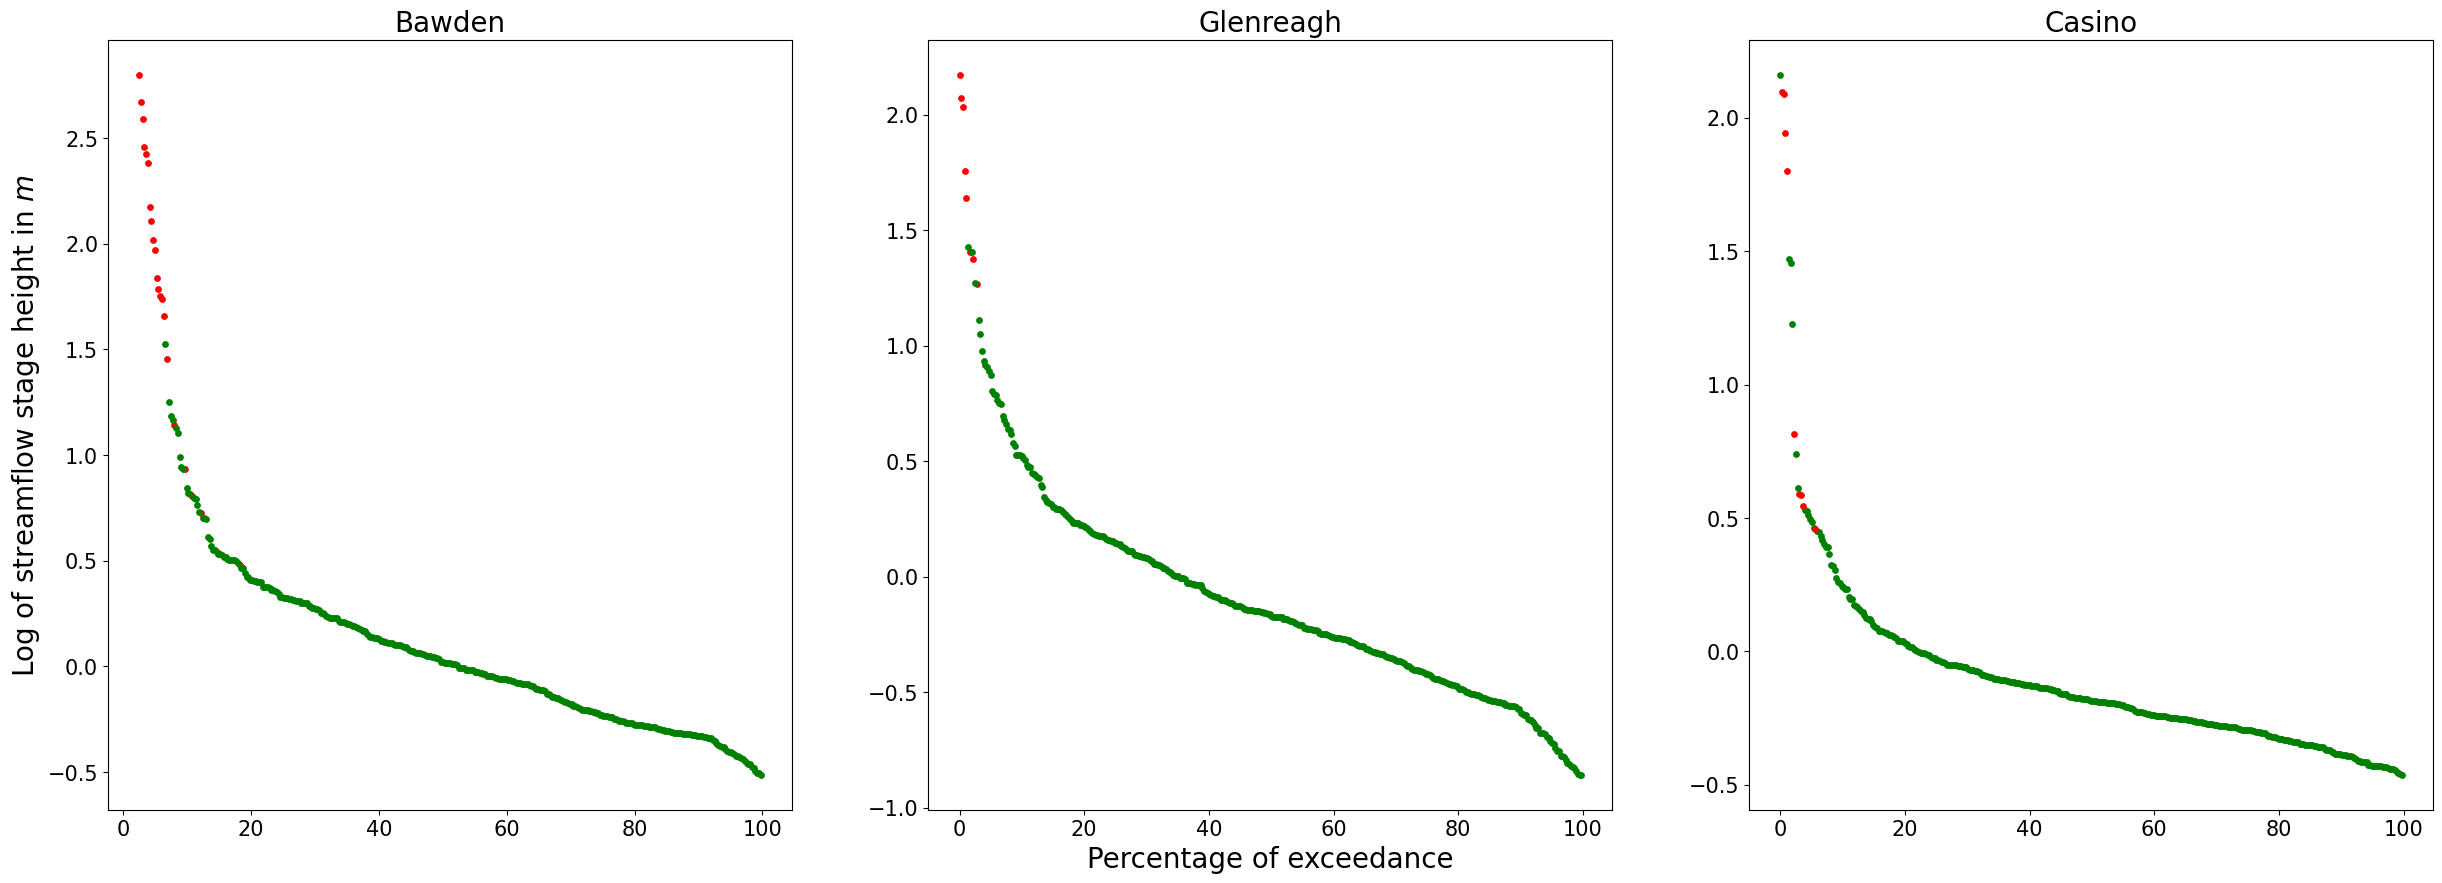

In [28]:
fig = plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3,)
(ax1, ax2, ax3) = gs.subplots()

ax3.scatter((fc_sort[switch_args1_c]*100),np.log(discharge_sort_c[switch_args1_c]),label = 'Model1 dominant', s=15, c='green')
ax3.scatter((fc_sort[switch_args2_c])*100,np.log(discharge_sort_c[switch_args2_c]),label = 'Model2 dominant', c='red',s=15)


ax1.scatter((fb_sort[switch_args2_b])*100,np.log(discharge_sort_b[switch_args2_b]),label = 'Model1 dominant', c='red',s=15)
ax1.scatter(fb_sort[switch_args1_b]*100,np.log(discharge_sort_b[switch_args1_b]),label = 'Model2 dominant', s=15, c='green')

ax2.scatter((fg_sort[switch_args2_g])*100,np.log(discharge_sort_g[switch_args2_g]),label = 'Model1 dominant', c='red',s=15)
ax2.scatter(fg_sort[switch_args1_g]*100,np.log(discharge_sort_g[switch_args1_g]),label = 'Model2 dominant', s=15, c='green')


ax2.xaxis.set_tick_params(labelsize=15)
ax2.yaxis.set_tick_params(labelsize=15)
ax3.xaxis.set_tick_params(labelsize=15)
ax3.yaxis.set_tick_params(labelsize=15)
ax1.xaxis.set_tick_params(labelsize=15)
ax1.yaxis.set_tick_params(labelsize=15)
ax1.set_title('Bawden',fontsize=20)
ax2.set_title('Glenreagh',fontsize=20)
ax3.set_title('Casino',fontsize=20)

ax1.set_ylabel('Log of streamflow stage height in $m$',fontsize=20)
ax2.set_xlabel('Percentage of exceedance',fontsize=20)


# Timeseries plots

In [3]:
# Orara river stations

from datetime import date, timedelta

start_date = date(2011, 1, 1) 
end_date = date(2012, 12, 31)    # perhaps date.now()

delta = end_date - start_date   # returns timedelta

date_labels = []
for i in range(delta.days + 1):
    day = start_date + timedelta(days=i)
    date_labels.append(str(day))

In [22]:
switch1 = np.where(preds_bawden['mix_weights_m2']<0.5,np.nan, 0)
switch2 = np.where(preds_bawden['mix_weights_m2']>=0.5,np.nan, 0)
missing_days = np.where(np.isnan(preds_bawden['obs']), -0.5, np.nan)

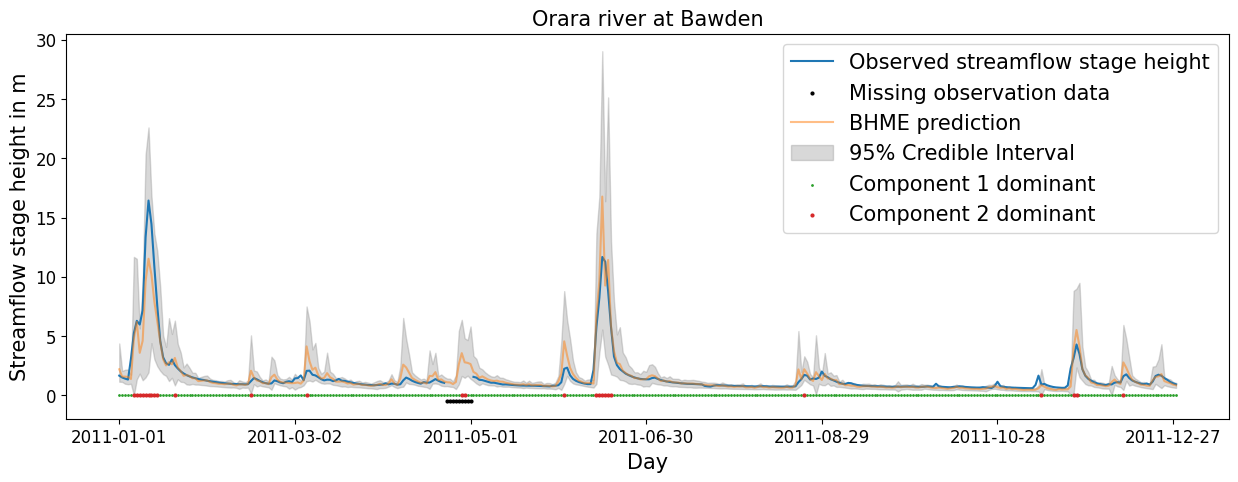

In [5]:
plt.figure(figsize=(15,5))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.plot(preds_bawden['obs'], label = 'Observed streamflow stage height')
plt.scatter([x for x in range(len(preds_bawden['obs']))],missing_days, label = 'Missing observation data', s=4, c='black')
plt.plot(preds_bawden['preds_m2'], label = 'BHME prediction', alpha=0.5)

plt.fill_between([x for x in range(len(preds_bawden['preds_m2']))],preds_bawden['hpdi_m2'][0,0,:], preds_bawden['hpdi_m2'][1,0,:], label='95% Credible Interval', color='#808080', alpha=0.3)

plt.xticks(ticks=[x for x in range(0,len(preds_bawden['obs']),60)],labels=[date_labels[x] for x in range(0,len(preds_bawden['obs']),60)])
plt.scatter([x for x in range(len(preds_bawden['obs']))],switch2, label = 'Component 1 dominant', s=1, c='#2ca02c')
plt.scatter([x for x in range(len(preds_bawden['obs']))],switch1, label = 'Component 2 dominant', s=4, c='#d62728')

plt.title('Orara river at Bawden', fontsize=15)
plt.ylabel('Streamflow stage height in m', fontsize=15)
plt.xlabel('Day', fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [7]:
switch1 = np.where(preds_glenreagh['mix_weights_m2']<0.5,np.nan, 0)
switch2 = np.where(preds_glenreagh['mix_weights_m2']>=0.5,np.nan, 0)
missing_days = np.where(np.isnan(preds_glenreagh['obs']), -0.5, np.nan)

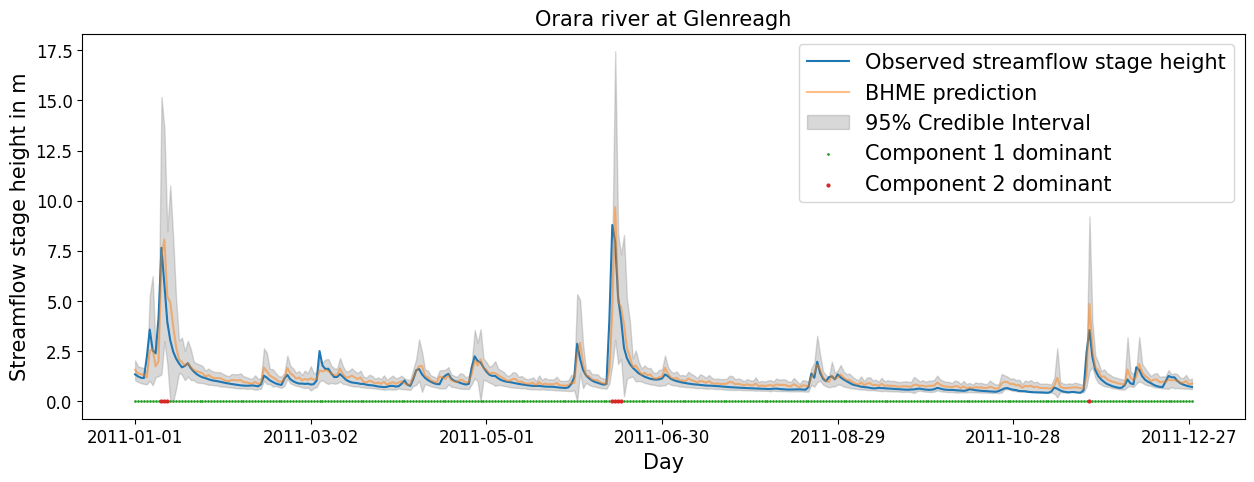

In [8]:
plt.figure(figsize=(15,5))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.plot(preds_glenreagh['obs'], label = 'Observed streamflow stage height')

plt.plot(preds_glenreagh['preds_m2'], label = 'BHME prediction', alpha=0.5)

plt.fill_between([x for x in range(len(preds_glenreagh['preds_m2']))],preds_glenreagh['hpdi_m2'][0,0,:], preds_glenreagh['hpdi_m2'][1,0,:], label='95% Credible Interval', color='#808080', alpha=0.3)

plt.xticks(ticks=[x for x in range(0,len(preds_glenreagh['obs']),60)],labels=[date_labels[x] for x in range(0,len(preds_glenreagh['obs']),60)])
plt.scatter([x for x in range(len(preds_glenreagh['obs']))],switch2, label = 'Component 1 dominant', s=1, c='#2ca02c')
plt.scatter([x for x in range(len(preds_glenreagh['obs']))],switch1, label = 'Component 2 dominant', s=4, c='#d62728')

plt.title('Orara river at Glenreagh', fontsize=15)
plt.ylabel('Streamflow stage height in m', fontsize=15)
plt.xlabel('Day', fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [35]:
# Richmond river stations

from datetime import date, timedelta

start_date = date(2015, 1, 1) 
end_date = date(2015, 12, 31)    

delta = end_date - start_date   

date_labels = []
for i in range(delta.days + 1):
    day = start_date + timedelta(days=i)
    date_labels.append(str(day))

In [34]:
switch1 = np.where(preds_richmond['mix_weights_m2']<0.5,np.nan, 0)
switch2 = np.where(preds_richmond['mix_weights_m2']>=0.5,np.nan, 0)
missing_days = np.where(np.isnan(preds_richmond['obs']), -0.5, np.nan)

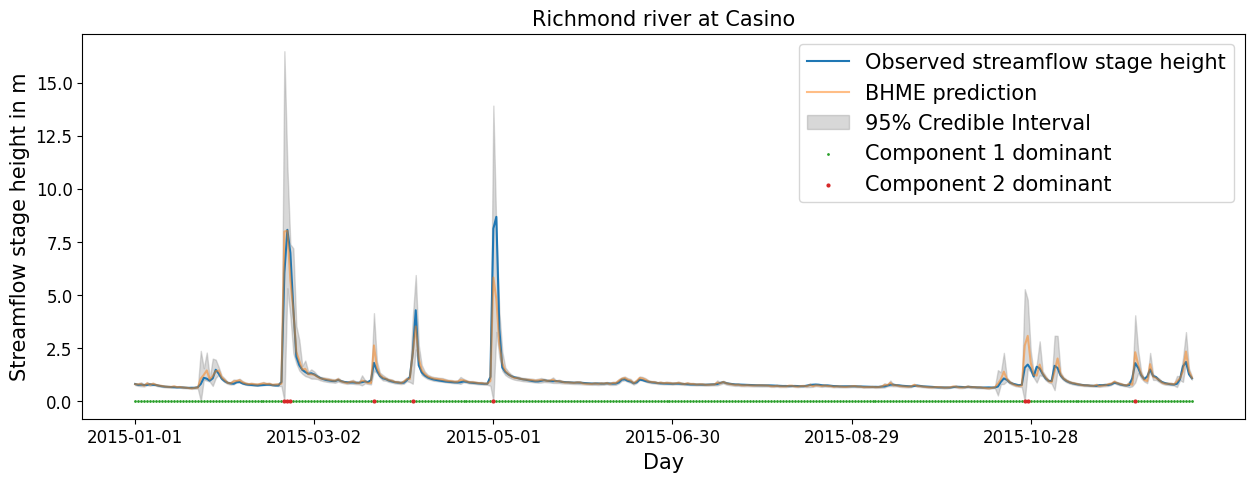

In [39]:
plt.figure(figsize=(15,5))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.plot(preds_richmond['obs'], label = 'Observed streamflow stage height')

plt.plot(preds_richmond['preds_m2'], label = 'BHME prediction', alpha=0.5)

plt.fill_between([x for x in range(len(preds_richmond['preds_m2']))],preds_richmond['hpdi_m2'][0,0,:], preds_richmond['hpdi_m2'][1,0,:], label='95% Credible Interval', color='#808080', alpha=0.3)

plt.xticks(ticks=[x for x in range(0,len(preds_richmond['obs']),60)],labels=[date_labels[x] for x in range(0,len(preds_richmond['obs']),60)])
plt.scatter([x for x in range(len(preds_richmond['obs']))],switch2, label = 'Component 1 dominant', s=1, c='#2ca02c')
plt.scatter([x for x in range(len(preds_richmond['obs']))],switch1, label = 'Component 2 dominant', s=4, c='#d62728')

plt.title('Richmond river at Casino', fontsize=15)
plt.ylabel('Streamflow stage height in m', fontsize=15)
plt.xlabel('Day', fontsize=15)
plt.legend(fontsize=15)
plt.show()

# Contour plot

In [2]:
# stage height data

#Downstream
bawden_stageheight_all = pd.read_csv('./../data/orara/stageheight_bawden.csv',skiprows=9)
bawden_stageheight_all['Date'] = pd.to_datetime(bawden_stageheight_all['#Timestamp'])

#Upstream
glenreagh_stageheight_all = pd.read_csv('./../data/orara/stageheight_glenreagh.csv',skiprows=9)
glenreagh_stageheight_all['Date'] = pd.to_datetime(glenreagh_stageheight_all['#Timestamp'])

In [3]:
# rain data

nanaglen_rain = pd.read_csv('./../data/orara/nana_glen.csv')
nanaglen_rain['dateInt']=nanaglen_rain['Year'].astype(str) + nanaglen_rain['Month'].astype(str).str.zfill(2)+ nanaglen_rain['Day'].astype(str).str.zfill(2)

nanaglen_rain['Date'] = pd.to_datetime(nanaglen_rain['dateInt'],format='%Y%m%d')

# time period decission

y_l = 2008
y_h = 2010

#slicing

dates_train = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].dt.date
dates_test = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].dt.date

hu_train = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].values
r_train = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_l)&(nanaglen_rain['Date'].dt.year<=y_h)].values
hd_train = bawden_stageheight_all['Value'][(bawden_stageheight_all['Date'].dt.year>=y_l)&(bawden_stageheight_all['Date'].dt.year<=y_h)].values

hu_test = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].values
r_test = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_h+1)&(nanaglen_rain['Date'].dt.year<=y_h+1)].values
hd_test = bawden_stageheight_all['Value'][(bawden_stageheight_all['Date'].dt.year>=y_h+1)&(bawden_stageheight_all['Date'].dt.year<=y_h+1)].values

ticklabels_train = dates_train.astype(str).values
ticklabels_test = dates_test.astype(str).values

def min_max_norm(x):
    return (x-x.min())/(x.max()-x.min())

def min_max_norm_t(x, min_val, max_val):
    return (x-min_val)/(max_val-min_val)

In [4]:
# test data

hu_test = hu_test[:-1]
r_test = r_test[:-1]

hd_test = hd_test[1:]


hu_test = np.delete(hu_test,np.argwhere(np.isnan(r_test))[:,0])
hd_test = np.delete(hd_test,np.argwhere(np.isnan(r_test))[:,0])
r_test = np.delete(r_test,np.argwhere(np.isnan(r_test))[:,0])



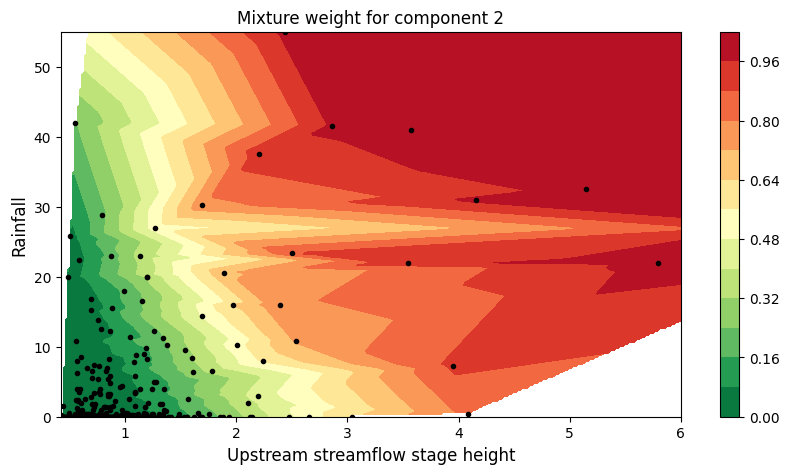

In [165]:
ngridx = 400
ngridy = 400
x = hu_test
y = r_test
z = preds_bawden['mix_weights_m2']

plt.figure(figsize=(10,5))
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


# Create grid values first.
xi = np.linspace(np.min(x), np.max(x), ngridx)
yi = np.linspace(np.min(y), np.max(y), ngridy)


from scipy.interpolate import griddata
zi = griddata((x, y), z, (xi[None, :], yi[:, None]), method='linear')

#ax1.contour(xi, yi, zi, levels=14, linewidths=0.5, colors='k')
plt.contourf(xi, yi, zi, levels=14, cmap="RdYlGn_r")

plt.colorbar()
plt.plot(x, y, 'ko', ms=3)
plt.xlim(np.min(x), 6)
plt.ylim(np.min(y),55)
plt.xlabel('Upstream streamflow stage height', fontsize=12)
plt.ylabel('Rainfall', fontsize=12)
plt.title('Mixture weight for component 2', fontsize=12)


plt.show()

# BHME density

In [168]:
with open('./../../results/bawden/bawden_m2', 'rb') as fp:
    trace_bawden = pickle.load(fp)

In [247]:
mu1_mean = np.mean(trace_bawden['mean1'][:,0,:], axis=0)
mu2_mean = np.mean(trace_bawden['mean2'][:,0,:], axis=0)

sd1_mean = np.mean(trace_bawden['sd1'][:,0,:], axis=0)
sd2_mean = np.mean(trace_bawden['sd2'][:,0,:], axis=0)

In [308]:
w = preds_bawden['mix_weights_m2'][52]

Array(0.34596154, dtype=float32)

In [309]:
gam1 = st.gamma(mu1_mean[98]*2/sd1_mean[52]**2,scale=sd1_mean[52]**2/mu1_mean[52])
gam2 = st.gamma(mu2_mean[98]*2/sd2_mean[52]**2,scale=sd2_mean[52]**2/mu2_mean[52])

In [341]:
gam1s = gam1.rvs(size=5000)
gam2s = gam2.rvs(size=5000)

<AxesSubplot: ylabel='Density'>

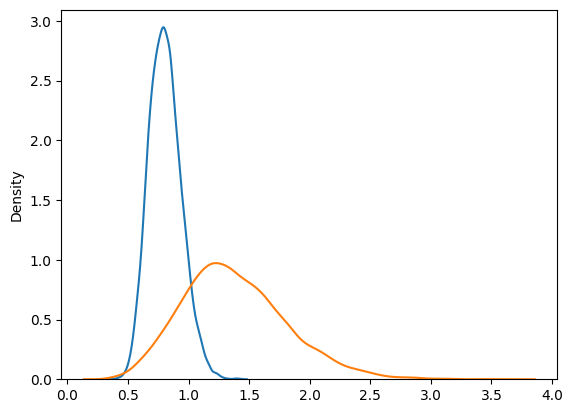

In [318]:
sns.kdeplot(gam1s)
sns.kdeplot(gam2s)


In [340]:
mix_den = []
for i in range(10000):
    if st.bernoulli.rvs(w) == 1:
        mix_den.append(gam2.rvs())
    else:
        mix_den.append(gam1.rvs())

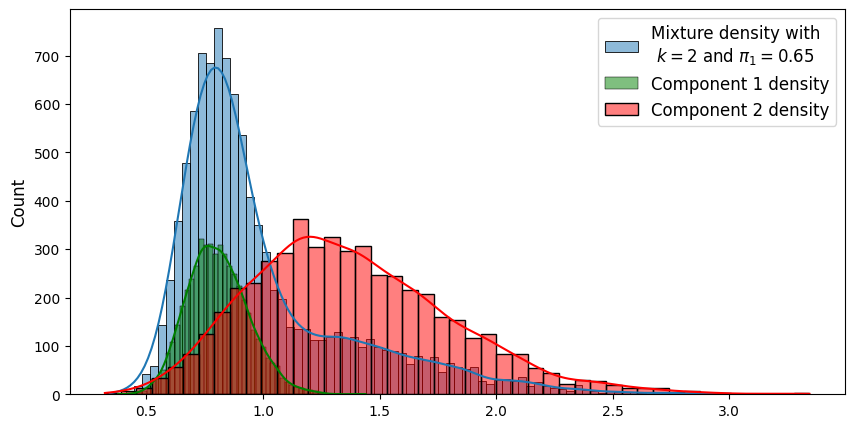

In [351]:
plt.figure(figsize=(10,5))
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.histplot(mix_den, kde=True, label = 'Mixture density with \n $k = 2$ and $\pi_1 = 0.65$')
sns.histplot(gam1s, kde=True, color='green', label = 'Component 1 density')
sns.histplot(gam2s, kde=True, color='red', label='Component 2 density')
plt.ylabel('Count',fontsize=12)
plt.legend(fontsize=12)